In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
#%load_ext line_profiler
#%load_ext snakeviz
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import corner

import pickle

import enterprise
from enterprise.pulsar import Pulsar
import enterprise.signals.parameter as parameter
from enterprise.signals import utils
from enterprise.signals import signal_base
from enterprise.signals import selections
from enterprise.signals.selections import Selection
from enterprise.signals import white_signals
from enterprise.signals import gp_signals
from enterprise.signals import deterministic_signals
import enterprise.constants as const

from enterprise_extensions import deterministic

from scipy.stats import norm

import libstempo as T2
import libstempo.toasim as LT
import libstempo.plot as LP

import glob
import json
import h5py
import healpy as hp
import scipy.constants as sc
import emcee

from numba.typed import List

import sys
import h5py
from enterprise_extensions import model_utils
from matplotlib import colors

In [2]:
#COMMENT IF OUTFILE GENERATED
#Thinning script for one source
i = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_broad_UL_outfile.h5"

infile = i
first_n_param = 8
# outfile = '/scratch/na00078/QuickCW_targeted_runs/results/3C66B_outfile.h5'

print(infile)
print(first_n_param)

with h5py.File(infile, 'r') as f:
    Ts = f['T-ladder'][...]
    samples_cold = f['samples_cold'][:,:,:first_n_param]
    print(samples_cold[-1].shape)
    log_likelihood = f['log_likelihood'][:1,:]
    print(log_likelihood.shape)
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
    acc_fraction = f['acc_fraction'][...]
    fisher_diag = f['fisher_diag'][...]

/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_broad_UL_outfile.h5
8
(100000000, 8)
(1, 100000000)


In [3]:
'''
timdir2 = '/scratch/na00078/MDC/mdc2/group2/dataset_1/tim/'
pardir2 = '/scratch/na00078/MDC/mdc2/group2/dataset_1/par/'

parfiles = sorted(glob.glob(pardir2 + '*.par'))
timfiles = sorted(glob.glob(timdir2 + '*.tim'))
psrs = []

for p, t in zip(parfiles, timfiles):
    psr = Pulsar(p, t)
    psrs.append(psr)
    
print(len(psrs))
'''

"\ntimdir2 = '/scratch/na00078/MDC/mdc2/group2/dataset_1/tim/'\npardir2 = '/scratch/na00078/MDC/mdc2/group2/dataset_1/par/'\n\nparfiles = sorted(glob.glob(pardir2 + '*.par'))\ntimfiles = sorted(glob.glob(timdir2 + '*.tim'))\npsrs = []\n\nfor p, t in zip(parfiles, timfiles):\n    psr = Pulsar(p, t)\n    psrs.append(psr)\n    \nprint(len(psrs))\n"

In [4]:
'''
#load psr names only if we want to save RAM
class psr_name:
    def __init__(self, name):
        self.name = name

psrListFile = "/scratch/na00078/MDC/mdc2/group2/dataset_2/noisefiles/psrlist_MDC_group2_dataset2.txt"

psrs = []
with open(psrListFile, 'r') as fff:
    for line in fff:
        psrname = line.strip()
        #print(psrname)
        psrs.append(psr_name(psrname))
        
print(len(psrs))
for i,psr in enumerate(psrs):
    print(str(i) + ": " + psr.name)
'''

'\n#load psr names only if we want to save RAM\nclass psr_name:\n    def __init__(self, name):\n        self.name = name\n\npsrListFile = "/scratch/na00078/MDC/mdc2/group2/dataset_2/noisefiles/psrlist_MDC_group2_dataset2.txt"\n\npsrs = []\nwith open(psrListFile, \'r\') as fff:\n    for line in fff:\n        psrname = line.strip()\n        #print(psrname)\n        psrs.append(psr_name(psrname))\n        \nprint(len(psrs))\nfor i,psr in enumerate(psrs):\n    print(str(i) + ": " + psr.name)\n'

In [5]:
'''
KPC2S = sc.parsec / sc.c * 1e3
SOLAR2S = sc.G / sc.c ** 3 * 1.98855e30


xxx0 = {"0_cos_gwtheta":np.cos(0.6387905062299246),
       "0_cos_inc":0.8412486994612669,
       "0_gwphi":3.3335788713091694,
       "0_log10_fgw":np.log10(3.7e-09),
       "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651,
        "distance": 75.4,}


xxx = {
       "0_cos_inc":0.8412486994612669,
        "0_log10_fgw":np.log10(3.7e-09),
        "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651}

xxx['gwb_gamma'] = np.nan    
xxx['gwb_log10_A'] = -15.070581074285707
    
#print(xxx)

# In[6]:


'''

'\nKPC2S = sc.parsec / sc.c * 1e3\nSOLAR2S = sc.G / sc.c ** 3 * 1.98855e30\n\n\nxxx0 = {"0_cos_gwtheta":np.cos(0.6387905062299246),\n       "0_cos_inc":0.8412486994612669,\n       "0_gwphi":3.3335788713091694,\n       "0_log10_fgw":np.log10(3.7e-09),\n       "0_log10_h":-13.668773493298787,\n       "0_log10_mc":np.log10(4300000000),\n       "phase0": 0.24434609527920614,\n        "psi": 1.1187560505283651,\n        "distance": 75.4,}\n\n\nxxx = {\n       "0_cos_inc":0.8412486994612669,\n        "0_log10_fgw":np.log10(3.7e-09),\n        "0_log10_h":-13.668773493298787,\n       "0_log10_mc":np.log10(4300000000),\n       "phase0": 0.24434609527920614,\n        "psi": 1.1187560505283651}\n\nxxx[\'gwb_gamma\'] = np.nan    \nxxx[\'gwb_log10_A\'] = -15.070581074285707\n    \n#print(xxx)\n\n# In[6]:\n\n\n'

In [6]:
#Enter dL value

target_d_L = 75.4

hamp [1.8796559e-17 9.3856960e-15 1.0641558e-15 ... 3.8276186e-14 3.9394804e-14
 3.9394804e-14]
freq [1.2984144e-08 1.1251759e-08 7.4217006e-09 ... 9.9419557e-09 9.9419557e-09
 9.9419557e-09]
mc [3.8819533e+10 6.5240605e+10 7.6151854e+09 ... 4.4283519e+10 4.4283519e+10
 4.4283519e+10]
Length of logdL 100000000
required values 8.806164 8.483024e-09 27147040000.0 7.801456e-15
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [7.7729250e+06 3.3613523e+04 6.2627949e+03 ... 3.9788684e+03 3.8658882e+03
 3.8658882e+03]
min 10**log10_d_L 0.001442976
max 10**log10_d_L 639976100.0
d_L_mask [   47197    52679    53372 ... 99929968 99929969 99929970]
notd_L_mask1 [   47447    47448    50038 ... 99930997 99930998 99930999]
notd_L_mask2 [       0        1        2 ... 99999997 99999998 99999999]
merged_non_dL [   47447    47448    50038 ... 99999997 99999998 99999999]


Sample shape (100000000, 9)
dL_mask length 24052
6
Max Mc sampled 9.911766


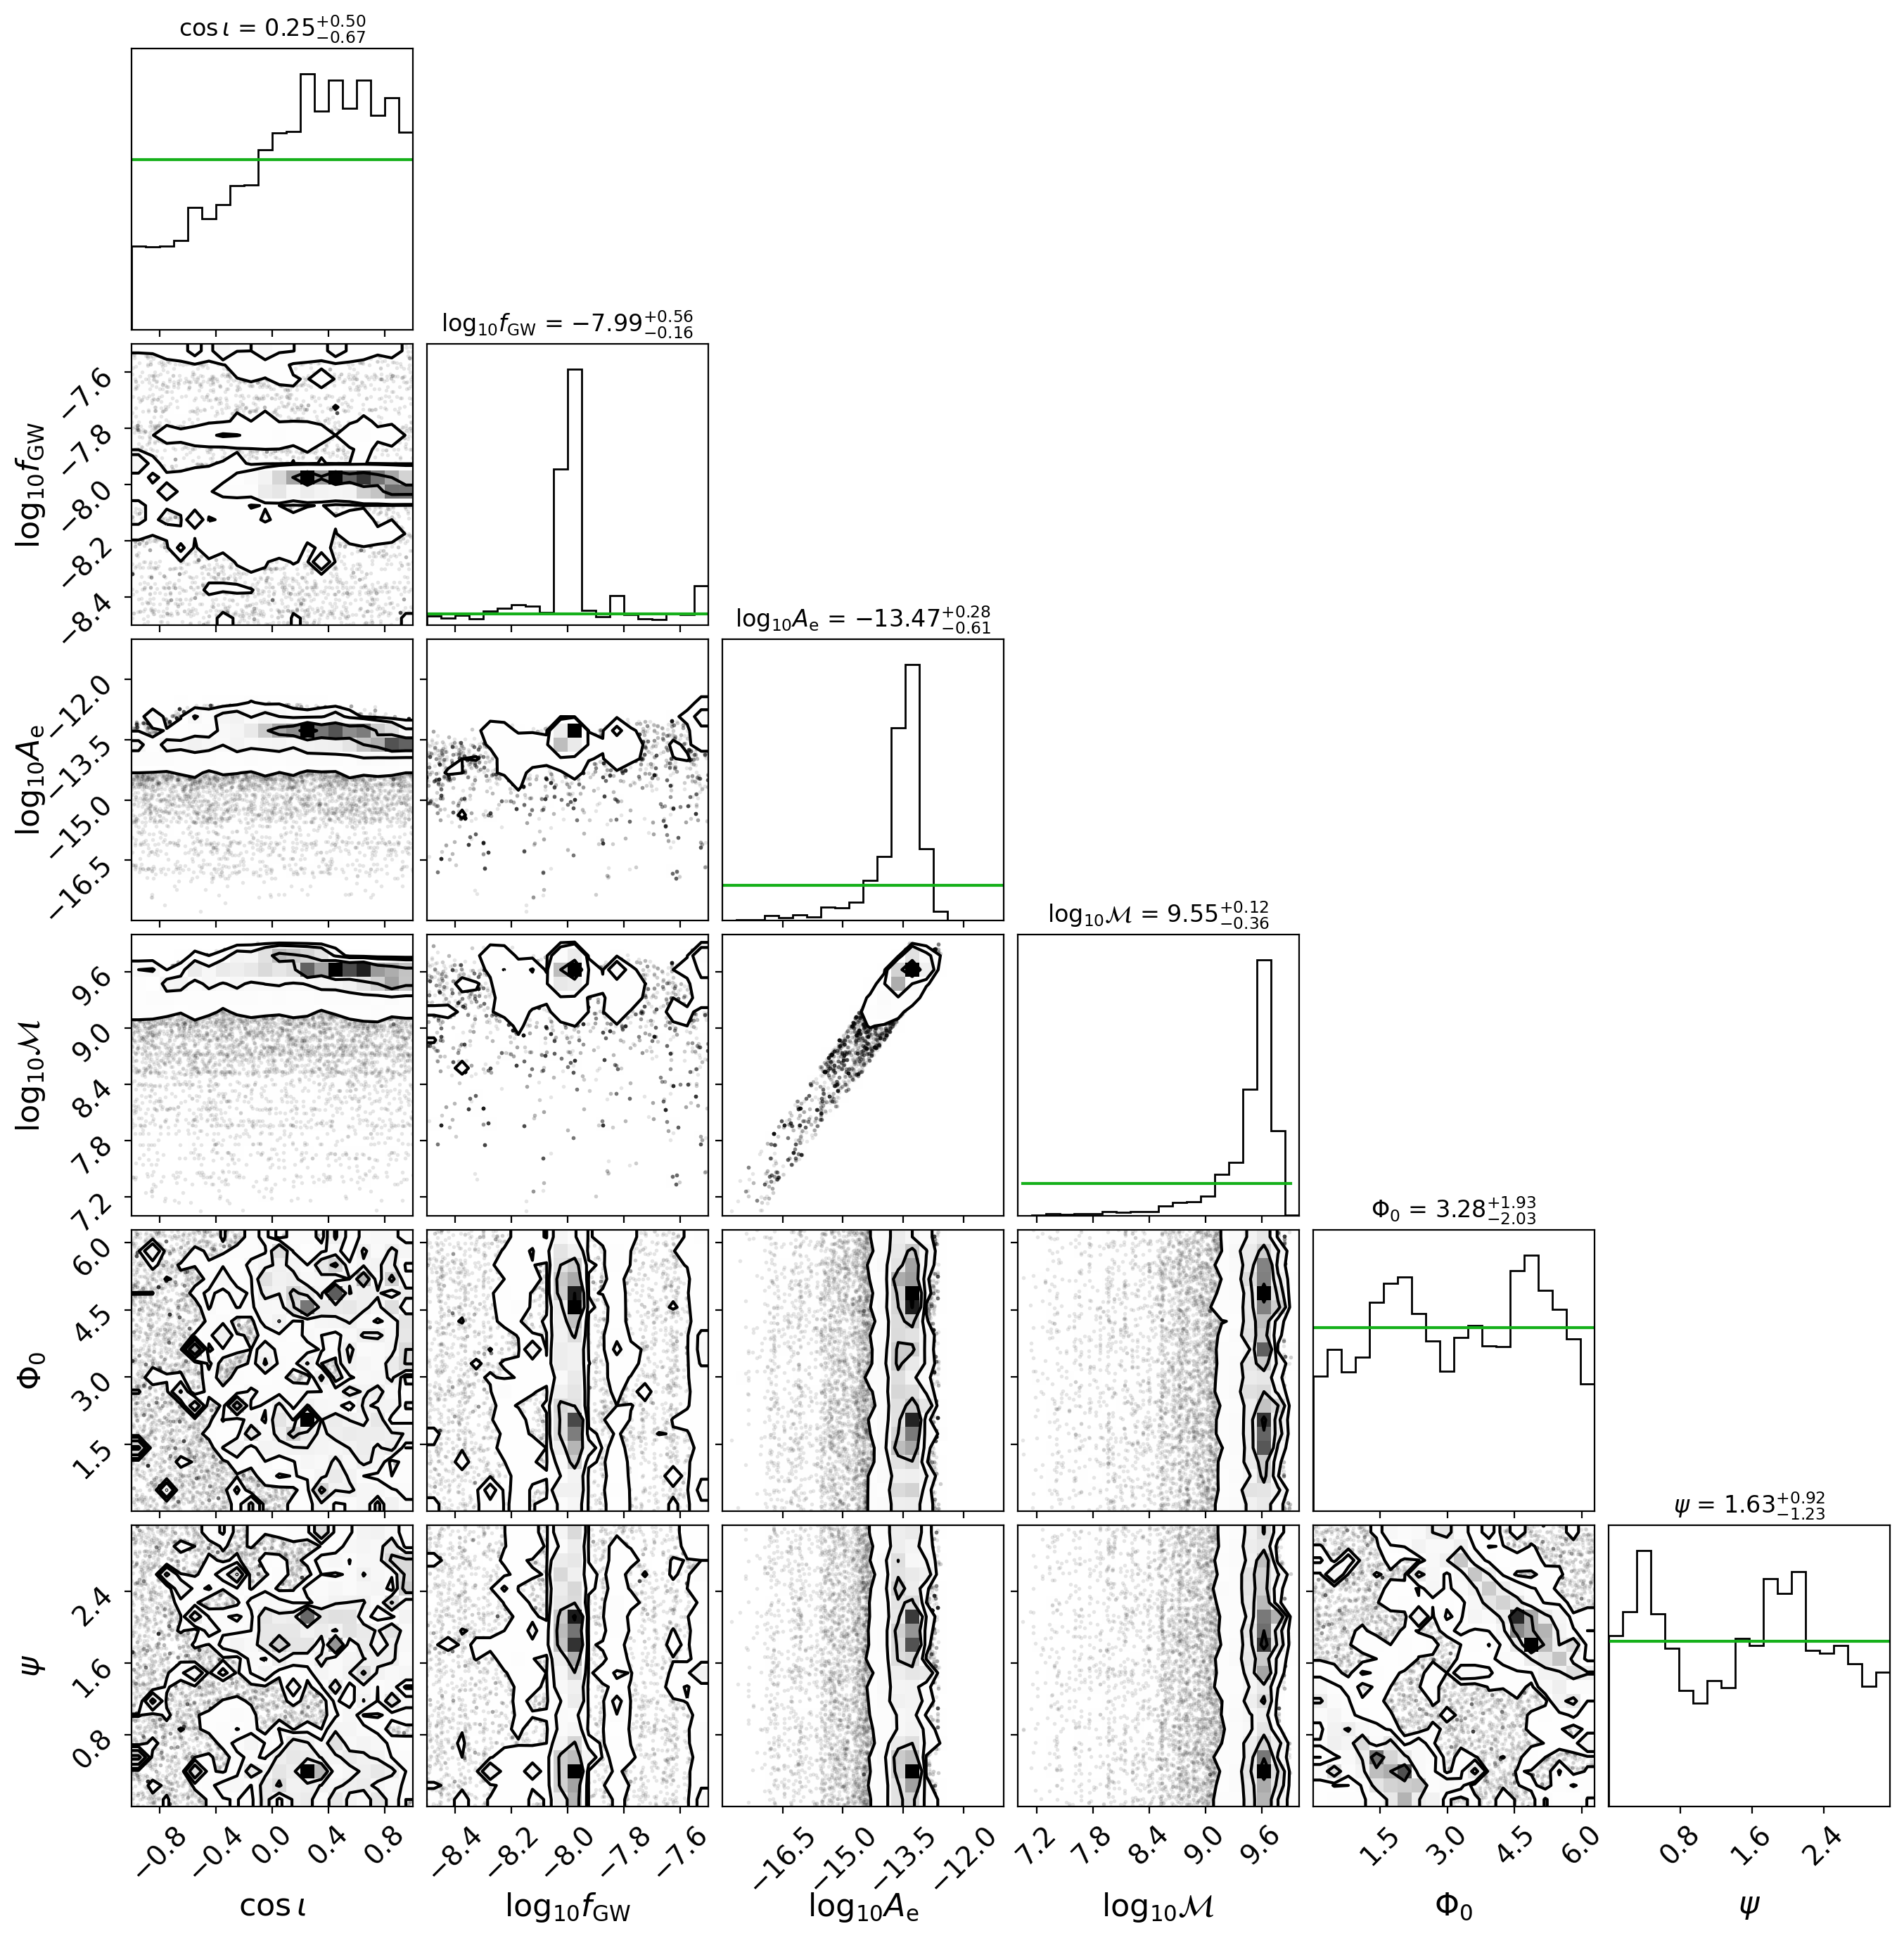

In [7]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
#labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
      #    r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
labels = [r"$\cos \iota$", r"$\log_{10} f_{\rm GW}$", r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$",r"$\psi$"]

label_to_key = {
    r"$\cos \iota$": "0_cos_inc",
     r"$\log_{10} f_{\rm GW}$":"0_log10_fgw",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi"
}

# Now build the truths array by translating labels
#truths = [xxx[label_to_key[l]] for l in labels]


#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-8.5,-7.5), (-18,-11), (7,10), (0,2*np.pi), (0,np.pi)]
#ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.704,np.log10(3e-7)), (-18,-11), (6.6,12), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################

d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)

#########################
not_d_L_mask_1 = np.where((10**log10_d_L<d_L_min))[0] #& (10**log10_d_L>d_L_max))[0]
print("notd_L_mask1",not_d_L_mask_1)
not_d_L_mask_2 = np.where((10**log10_d_L>d_L_max))[0] #& ())[0]
print("notd_L_mask2",not_d_L_mask_2)

merged_non_dL = np.concatenate((not_d_L_mask_1,not_d_L_mask_2))
print("merged_non_dL",merged_non_dL)
########################################

samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

print("Max Mc sampled", np.max(samples2plot[d_L_mask,5]))

samples2plot_detect = np.vstack((
                          samples2plot[d_L_mask,1],
                            samples2plot[d_L_mask,3],
                          samples2plot[d_L_mask,4],
                          samples2plot[d_L_mask,5],
                          samples2plot[d_L_mask,6],
                          samples2plot[d_L_mask,7])).T


#fig = corner.corner(samples2plot_detect,
  #                  labels=labels,
   #                 show_titles=True, quantiles=[0.16, 0.5, 0.84],
    #                range=ranges, hist_kwargs={"density":True})
    
fig = corner.corner(
    samples2plot_detect,
    labels=labels,
    show_titles=True,
    range=ranges,
    hist_kwargs={"density": True})

for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)   # tick labels
    ax.xaxis.label.set_size(16)                 # x-axis label
    ax.yaxis.label.set_size(16)                 # y-axis label

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0:#(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==(len(labels)+1): #log10_fgw
         Xs = np.linspace(-9, np.max(samples2plot[d_L_mask,3]))
         ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==2*(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==3*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(np.min(samples2plot[d_L_mask,5]), np.max(samples2plot[d_L_mask,5]))
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==4*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==5*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")

#fig.suptitle(crnr_plt_title1, fontsize = 25,y=1.05);

7.052412e+00
9.911766


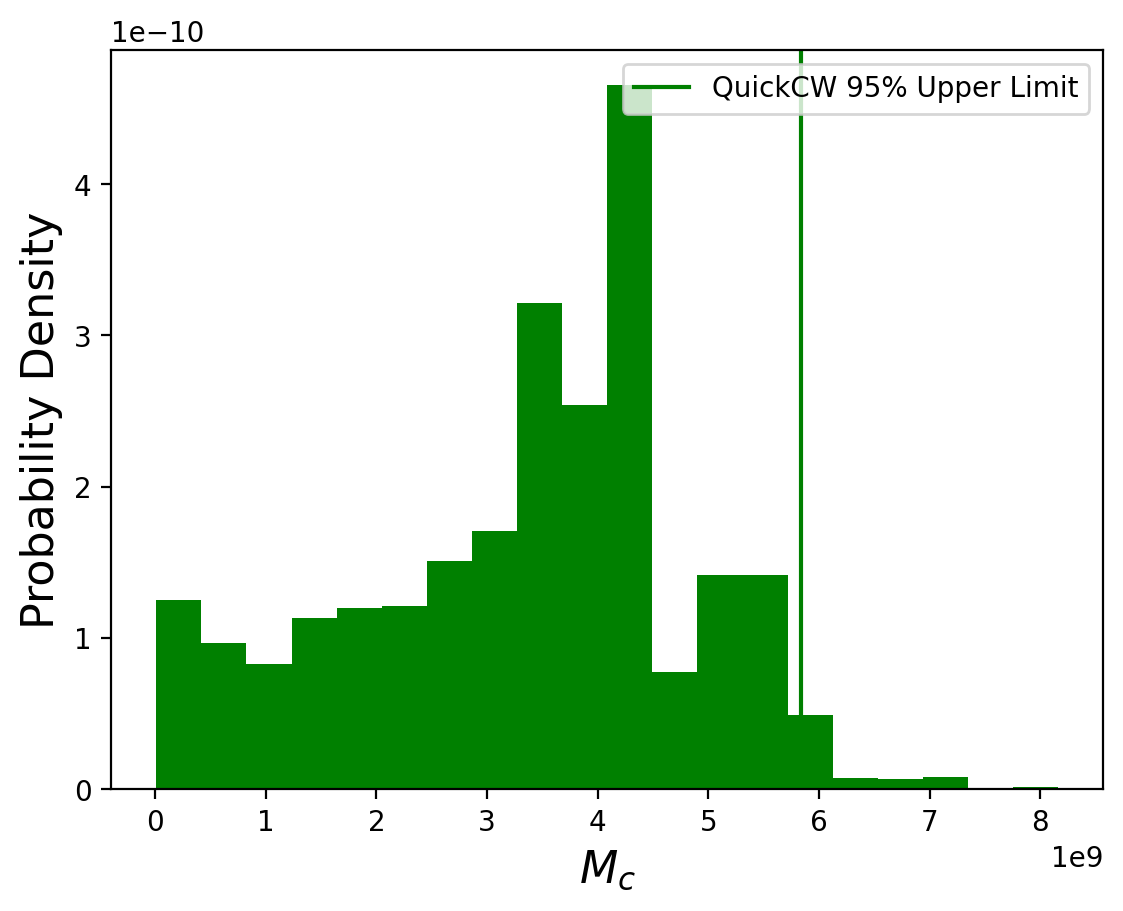

5.600676352
9.748240476685586
9.748240476685586


In [8]:
#dL Mc Upper limit

logMcmin_dL = np.min(samples2plot[d_L_mask,5])
logMcmax_dL = np.max(samples2plot[d_L_mask,5])

#print(samples2plot[d_L_mask,5])
#print(np.power(10,samples2plot[d_L_mask,5]))

print(logMcmin_dL)
print(logMcmax_dL)

plt.hist(np.power(10,samples2plot[d_L_mask,5]), bins=20, density=True,color='green')
#plt.hist(bjorn_UL, bins=20, density=True,color='blue', alpha = 0.5)
plt.axvline(x = 5838170214.399944,color='green',label= "QuickCW 95% Upper Limit")
#plt.axvline(x = 5539651847.030904,color='blue',label= "Enterprise 95% Upper Limit")
#plt.title("NGC3115 Upper Limit Mc histogram (with dL masking)", y=1.05)
plt.xlabel("$M_c$",fontsize = 16)
plt.ylabel("Probability Density", fontsize = 16)
plt.legend(loc='upper right')
plt.show()

x = np.quantile(np.power(10,samples2plot[d_L_mask,5]), 0.95)
print(x/1e9)
print(np.log10(x))
#y = np.quantile(bjorn_UL, 0.95)
#print(y/1e9)
print(np.log10(x))

In [9]:
print(np.max(samples2plot[d_L_mask,4]))

-12.581399


In [10]:
fmax=np.max(10**samples2plot[d_L_mask,3])
fmin=np.min(10**samples2plot[d_L_mask,3])
print(fmin)

T = 2.1192508e-09
bins = fmax-fmin
print(bins/T)
print(fmax,fmin)
print(T*46)

2.1192508e-09
46.14195225227489
9.990562e-08 2.1192508e-09
9.74855368e-08


In [11]:
print(samples2plot[d_L_mask,3][10])

-7.155399


In [12]:
T = 2.1192508e-09  # Step size for vals
fmax = np.max(10 ** samples2plot[d_L_mask, 3])  # Maximum value from your data
fmin = np.min(10 ** samples2plot[d_L_mask, 3])  # Minimum value from your data

# Create a list of values starting from fmin and incrementing by T until fmax
vals = []
while fmin < fmax:
    vals.append(fmin)
    fmin += T

# Print the length of vals for debugging (optional)
#print(len(vals) - 1)
#print(vals[0],vals[1])
# Find the indices in samples2plot[d_L_mask, 3] that are between consecutive values in vals
indices = []
inc = 0
for i, value in enumerate(10 ** samples2plot[d_L_mask, 3]):
    # Make sure that inc + 1 is a valid index in vals
    if inc < len(vals)-1:
        #print(inc)
        if vals[inc] >= value and value <=vals[inc+1]:
            #print(value)
            indices.append(i)
        inc += 1  # Increment inc only when condition is met
    else:
        break  # Exit the loop once you've processed all values in vals

# Output the indices
#print(indices)


In [13]:
#WORKS PROPERLY (DONT DELETE!!)
def calculate_mc(inc):
    
    
    T = 2.1192508e-09
    fmax=np.max(10**samples2plot[d_L_mask,3])
    fmin=np.min(10**samples2plot[d_L_mask,3])


    vals = []
    while fmin < fmax:
        #print(fmin)  # Round to 1 decimal place for better formatting
        vals.append(fmin)
        fmin += T

    indices=[]
    for i, value in enumerate(10**samples2plot[d_L_mask,3]):
        #print("at inc "+str(inc) +" I have " + str(i))
        if  value >= vals[inc] and value <=vals[inc+1]:
            #print ("MY VALUE "+str(value)+" is between "+str(vals[inc])+" and "+str(vals[inc+1]))
            indices.append(i)
        #inc += 1  # Increment inc only when condition is met 
    #print(indices)


    data_list= [10**samples2plot[d_L_mask[i],5] for i in indices]
    #print(len(data_list))
    return data_list


In [14]:
#WORKS PROPERLY (DONT DELETE!!)

arr = []

for i in range(0,46):
    arr.append(calculate_mc(i))

arr_len=[]
for i in range(0,46):
    arr_len.append(len(arr[i]))
#print(arr)
print(arr_len)
#plt.plot(fGW_vals,arr_len)




[2090, 1172, 1227, 10392, 1355, 393, 887, 171, 128, 160, 217, 204, 469, 670, 223, 207, 273, 118, 276, 322, 85, 69, 109, 360, 146, 147, 253, 184, 87, 106, 103, 133, 225, 87, 110, 64, 101, 165, 71, 92, 66, 55, 54, 54, 76, 72]


In [15]:
UL = []


for i in range(0,46):
    x = np.quantile(arr[i], 0.95)
    UL.append(x)
    
print(UL)
print(np.log10(UL))
print(len(UL))




[5283091693.906111, 5455487592.485572, 4322171868.891746, 5550234500.608465, 5473667203.614925, 4256186902.314152, 4328688693.494082, 4984442348.04577, 4566355722.088693, 3214253907.3336754, 4983884162.983303, 5820499938.7743435, 6888297210.748004, 6728319538.072877, 6077630902.023632, 4355146815.311935, 5001919914.808358, 4466310773.583813, 4887308434.737971, 3652543252.4046087, 4739542558.054957, 5726403455.528792, 5806582206.244473, 6102505167.21924, 5219563687.129105, 4788785365.695164, 4046872858.1424847, 4335290496.584577, 4948925592.141282, 5440784275.180669, 5327195117.221167, 4558190752.713744, 4834641980.782437, 2864346332.0565753, 4881044893.698524, 4355328526.319417, 3665873826.153388, 3242835150.595561, 3209111815.5748935, 3452453986.9456143, 3767039842.7899423, 3630066565.877821, 2686635540.015348, 3054025658.8151994, 2728048272.110395, 2918613468.9213815]
[9.72288815 9.73683357 9.63570203 9.74431133 9.73827839 9.62902069
 9.63635635 9.69761658 9.65956974 9.50708018 9.697

In [16]:
def UL_error_calc(n):
    global arr
    global UL
    counts, bin_edges, _ =plt.hist(arr[n], density=True)
    plt.axvline(x=UL[n],color='black')#,label= "15yr Upper Limit = 2.89e+10")
    #plt.axvline(x = 1.34e+09,color='red',label= "12.5yr Upper Limit = 1.34e+09 ")
    
    bin_index = np.digitize(UL[n], bin_edges) - 1  # -1 because digitize returns index starting from 1
    #print(bin_index)
    # Get the corresponding y value (the count in the appropriate bin)
    
    if bin_index < len(counts):
        y_value = counts[bin_index]
        #print(y_value)
    else:
        #print(f"Warning: bin_index {bin_index} is out of bounds.")
        y_value = 0  # Set to a default value or handle as needed
    
    '''
    y_value = counts[bin_index]
    #print('y_value',y_value.shape)
    '''
    sigma = np.sqrt((.95*.05)/len(arr[n]))/y_value
    #print(len(arr[n]))
    return sigma

<ipython-input-16-b5bfda37fb03>:23: RuntimeWarning: divide by zero encountered in double_scalars
  sigma = np.sqrt((.95*.05)/len(arr[n]))/y_value


[80279122.01680712, 31307807.669021048, 99235473.37884913, 11652769.272962322, 48791672.88904585, 99955894.40785322, 103006190.9913074, 153396345.86067924, 103796579.3674442, 242736220.410403, inf, inf, 51250625.48263743, 149461005.158994, 227696364.57969335, 32798762.827459045, 124626801.46931602, 823561452.8227355, 21266193.61675628, 14093917.399336843, 168608297.61986622, 266806147.7408189, 734708055.7714285, inf, 32719119.320968434, 28482431.664768904, 18865732.75429307, 155153211.25375104, 621841317.0718095, inf, inf, 71445138.4225168, 57609169.47619728, 82363059.65770982, inf, 152143247.8973189, 73021601.44392347, 235432653.8435875, 91887301.4674931, 113855317.72086777, inf, inf, 26126568.847450323, 175460022.68060964, 62465640.78397526, inf]


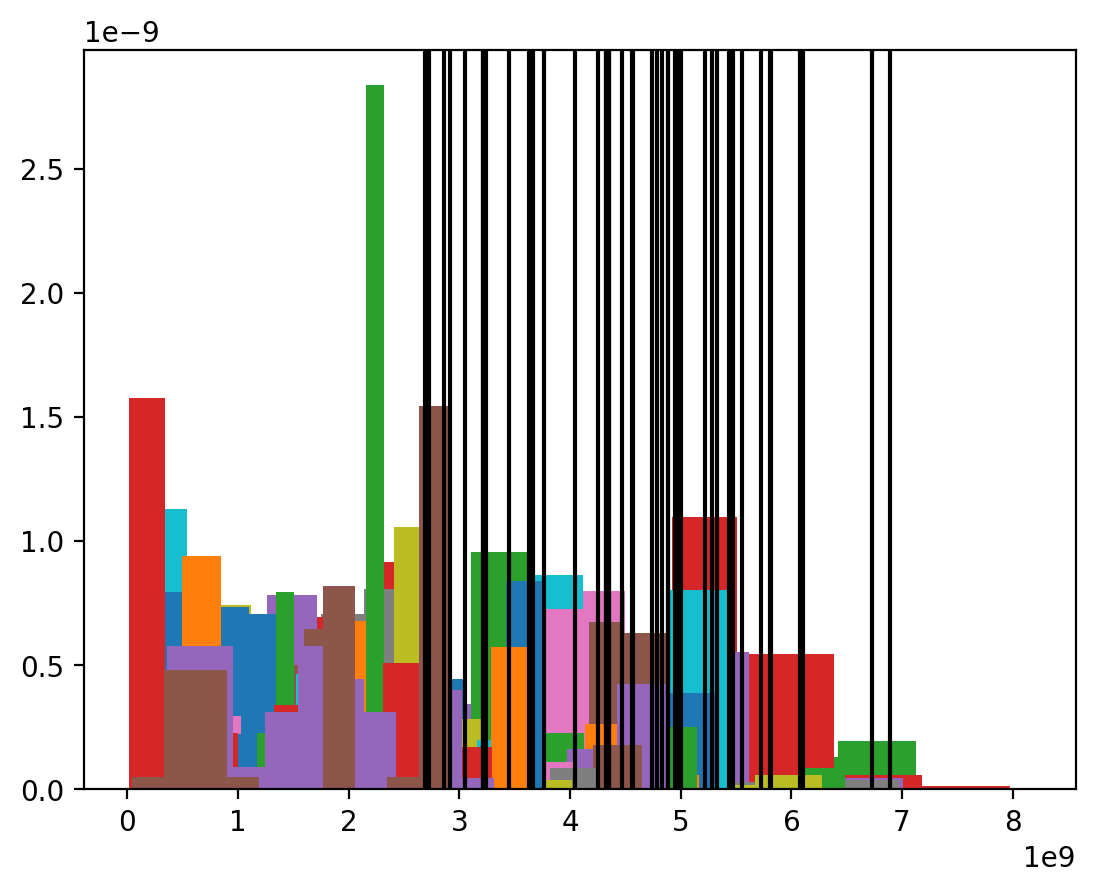

In [17]:
UL_error = []


for i in range(0,46):
    x = np.quantile(arr[i], 0.95)
    UL_error.append(UL_error_calc(i))
    
print(UL_error)

In [18]:

T = 2.1192508e-09
fmax=np.max(10**samples2plot[d_L_mask,3])
fmin=np.min(10**samples2plot[d_L_mask,3])


fGW_vals = []
while fmin < fmax:
    #print(fmin)  # Round to 1 decimal place for better formatting
    fGW_vals.append(fmin)
    fmin += T
    
print(fGW_vals.pop())    
print(fGW_vals)
print(len(fGW_vals))


9.9604787574868e-08
[2.1192508e-09, 4.238501574867964e-09, 6.357752374867964e-09, 8.477003174867963e-09, 1.0596253974867963e-08, 1.2715504774867962e-08, 1.4834755574867962e-08, 1.6954006374867963e-08, 1.9073257174867964e-08, 2.1192507974867965e-08, 2.3311758774867966e-08, 2.5431009574867968e-08, 2.755026037486797e-08, 2.966951117486797e-08, 3.178876197486797e-08, 3.390801277486797e-08, 3.602726357486797e-08, 3.814651437486797e-08, 4.026576517486797e-08, 4.2385015974867974e-08, 4.4504266774867975e-08, 4.6623517574867976e-08, 4.874276837486798e-08, 5.086201917486798e-08, 5.298126997486798e-08, 5.510052077486798e-08, 5.721977157486798e-08, 5.933902237486798e-08, 6.145827317486798e-08, 6.357752397486799e-08, 6.569677477486799e-08, 6.781602557486799e-08, 6.993527637486799e-08, 7.205452717486799e-08, 7.417377797486799e-08, 7.629302877486799e-08, 7.8412279574868e-08, 8.0531530374868e-08, 8.2650781174868e-08, 8.4770031974868e-08, 8.6889282774868e-08, 8.9008533574868e-08, 9.1127784374868e-08, 9

In [19]:
print(np.log10(3.956705614901995e-09))

-8.402666260721997


In [30]:
print((4.238501574867964+6.357752374867964)/2)
print(5.298126974867964-4.238501574867964)

5.298126974867964
1.0596253999999998


In [31]:

fGW_plot = []

for i in fGW_vals:
    fGW_plot.append(i-1.0596253999999998e-09)
    
#print(fGW_plot)

UL_by9 = []
for i in UL:
    UL_by9.append(i/1e9)
    
UL_w9 = []
for i in UL:
    UL_w9.append(i)

ULerr_by9 = []
for i in UL_error:
    ULerr_by9.append(i/1e9)

In [32]:
print("fGW_plot:", np.shape(fGW_plot))
print("UL_by9:", np.shape(UL_by9))
print("ULerr_by9:", np.shape(ULerr_by9))

fGW_plot: (46,)
UL_by9: (46,)
ULerr_by9: (46,)


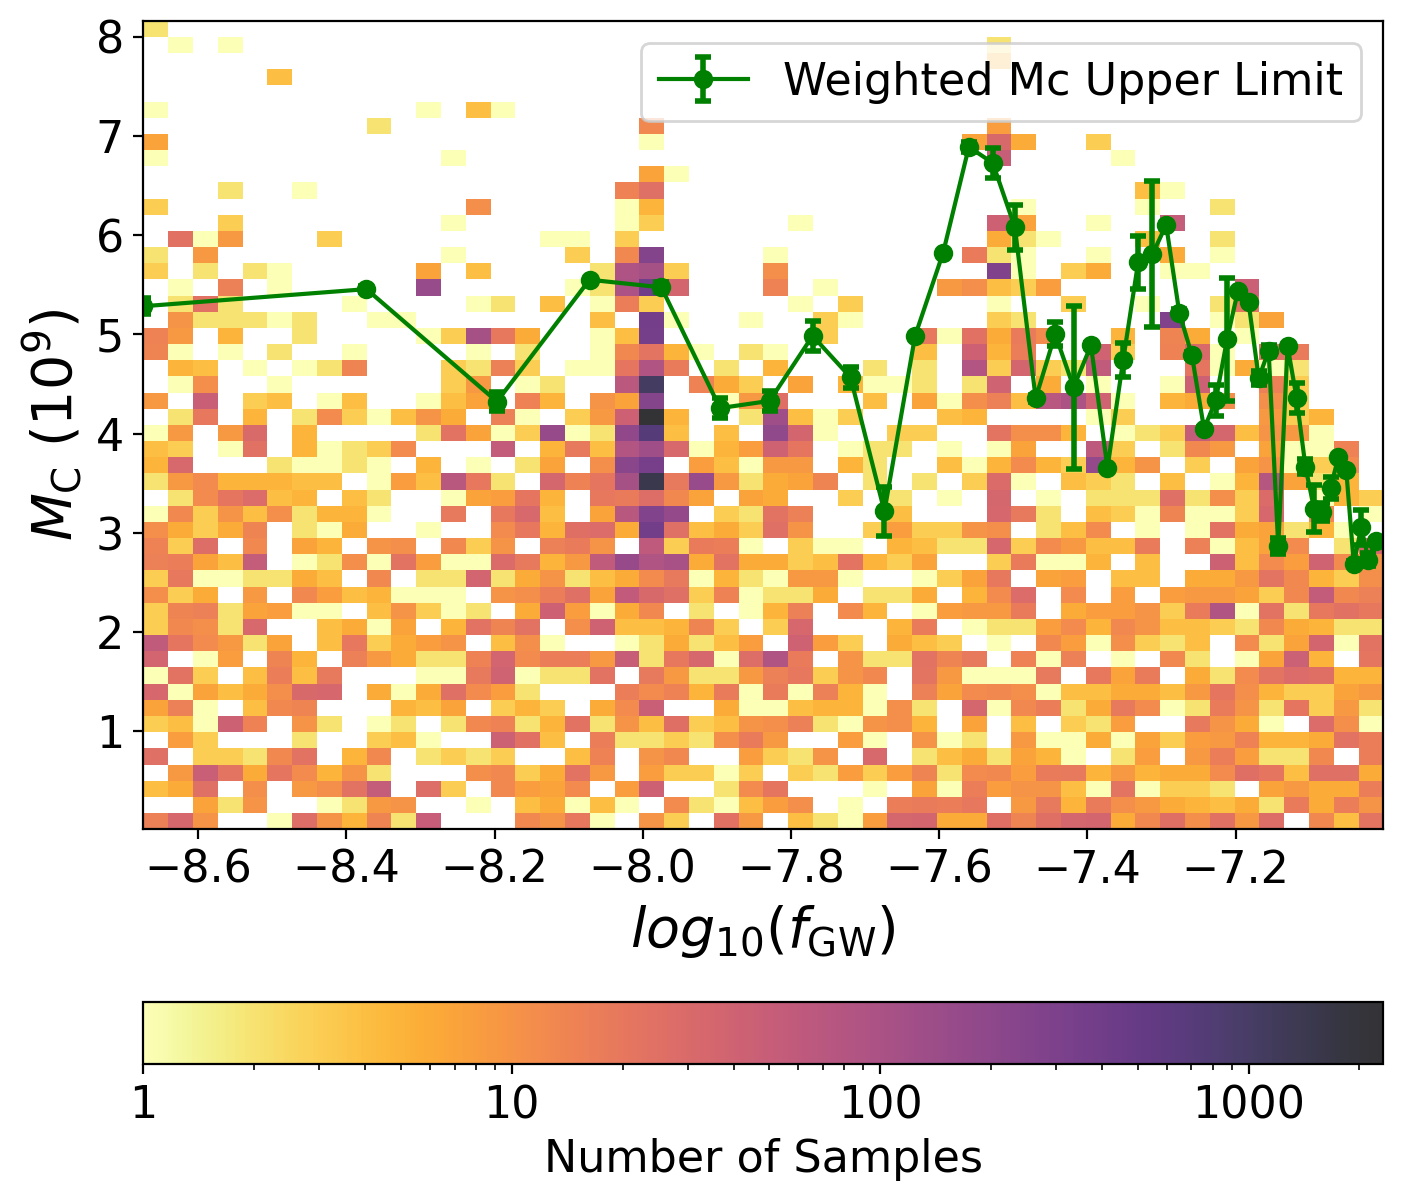

In [33]:
from matplotlib.ticker import ScalarFormatter
from matplotlib import colors

plt.rcParams['font.size'] = 16

fig, ax = plt.subplots(figsize=(8,7.5))
counts, xbins, ybins, image = ax.hist2d(
    samples2plot[d_L_mask, 3],   # log10(f_GW)
    (10**samples2plot[d_L_mask, 5]) / 1e9,  # Mc in 10^9 Msun
    bins=50,
    norm=colors.LogNorm(),
    alpha=0.8,
    cmap='inferno_r'
)
#ax.plot(np.log10(fGW_plot),np.log10(UL_vals))
#ax.axhline(1.17491e9/1e9, color="black",linestyle="--", label='Messier 077 Broad UL')


ax.errorbar(
    np.log10(fGW_vals), UL_by9, 
    yerr=ULerr_by9, 
    fmt='o', 
    color='g',
    ecolor='green',
    elinewidth=2, 
    capsize=3, 
    capthick=2, 
    linestyle='-', 
    label='Weighted Mc Upper Limit'
    
)

#ax.errorbar(np.log10(fGW_vals),UL_by9, yerr=ULerr_by9, fmt='o', color='mediumseagreen', 
 #            ecolor='mediumseagreen', elinewidth=2, capsize=3,zorder=1, capthick=2,linestyle='-',\
  #          label = 'Messier 077 Segmented UL')


cbar = plt.colorbar(image, ax = ax, label='Number of Samples', orientation='horizontal')
cbar.ax.xaxis.set_major_formatter(ScalarFormatter())
#cbar.ax.set_xticklabels(['10','$10^2$','$10^3$','$10^4$','$10^5$'])  # horizontal colorbar

plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
#plt.xlim(-8.5,-7)
#plt.ylim(0,9.9)
plt.xlabel('$log_{10}(f_{\mathrm{GW}})$', fontsize = 20)
plt.ylabel('$M_{\mathrm{C}}$ $(10^{9})$', fontsize = 20)
plt.legend()


In [24]:
'''
import numpy as np

# Arrays to save
# UL_w9 = np.array([...])
# fGW_vals = np.array([...])

# Check lengths
if len(UL_w9) != len(fGW_vals):
    raise ValueError("Arrays must have the same length!")

# Fixed path
base_path = "/scratch/na00078/projects/15yr_jet_sources/post_processing/txt_files/"

# Choose file name (change this each time)
file_name = "PKS183021_with_masking.txt"   # <-- change only this part

# Full path
outfile = base_path + file_name

# Save
data = np.column_stack((UL_w9, fGW_vals))
np.savetxt(outfile, data, fmt="%r", header="UL_w9   fGW_vals")

print(f"Saved file: {outfile}")

'''

'\nimport numpy as np\n\n# Arrays to save\n# UL_w9 = np.array([...])\n# fGW_vals = np.array([...])\n\n# Check lengths\nif len(UL_w9) != len(fGW_vals):\n    raise ValueError("Arrays must have the same length!")\n\n# Fixed path\nbase_path = "/scratch/na00078/projects/15yr_jet_sources/post_processing/txt_files/"\n\n# Choose file name (change this each time)\nfile_name = "PKS183021_with_masking.txt"   # <-- change only this part\n\n# Full path\noutfile = base_path + file_name\n\n# Save\ndata = np.column_stack((UL_w9, fGW_vals))\nnp.savetxt(outfile, data, fmt="%r", header="UL_w9   fGW_vals")\n\nprint(f"Saved file: {outfile}")\n\n'

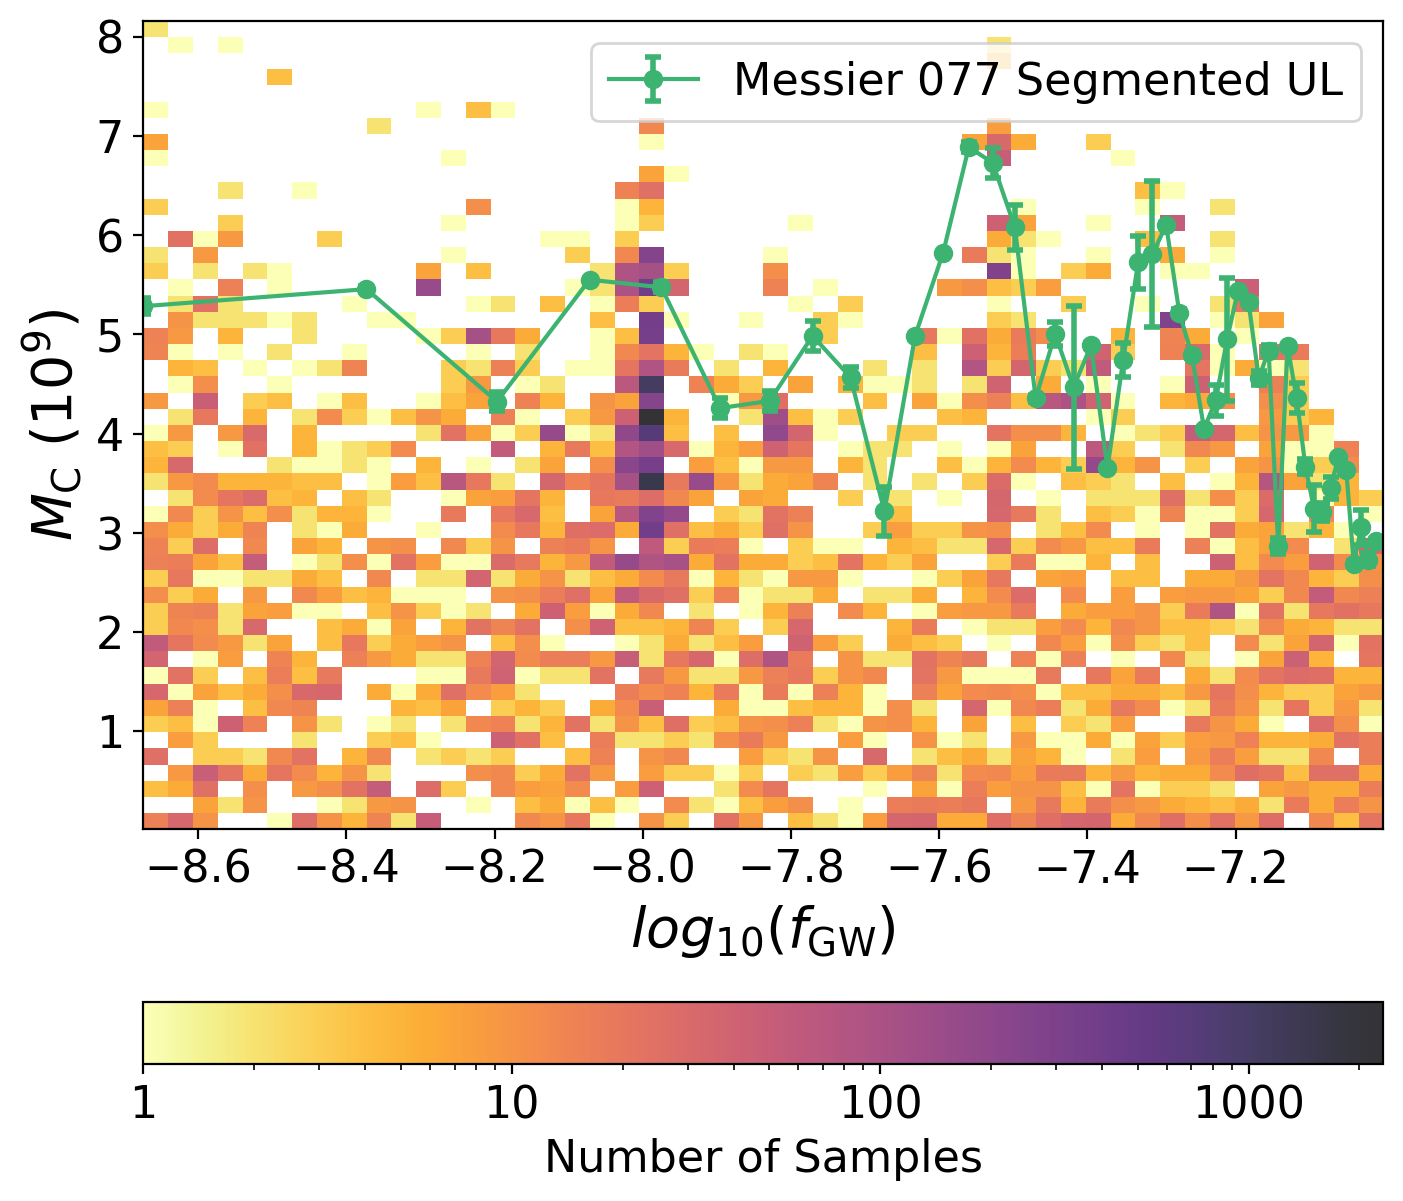

In [25]:
#Jessica run

from matplotlib.ticker import ScalarFormatter
from matplotlib import colors

plt.rcParams['font.size'] = 16

fig, ax = plt.subplots(figsize=(8,7.5))
counts,xbins,ybins,image = ax.hist2d(samples2plot[d_L_mask,3], (10**samples2plot[d_L_mask,5])/1e9, bins=50, 
                                     norm=colors.LogNorm(), alpha = 0.8, cmap = 'inferno_r')
#ax.plot(np.log10(fGW_plot),np.log10(UL_vals))
#ax.axhline(1.17491e9/1e9, color="black",linestyle="--", label='Messier 077 Broad UL')


ax.errorbar(np.log10(fGW_vals),UL_by9, yerr=ULerr_by9, fmt='o', color='mediumseagreen', 
             ecolor='mediumseagreen', elinewidth=2, capsize=3,zorder=1, capthick=2,linestyle='-',\
            label = 'Messier 077 Segmented UL')




cbar = plt.colorbar(image, ax = ax, label='Number of Samples', orientation='horizontal')
cbar.ax.xaxis.set_major_formatter(ScalarFormatter())
#cbar.ax.set_xticklabels(['10','$10^2$','$10^3$','$10^4$','$10^5$'])  # horizontal colorbar

plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
#plt.xlim(-8.5,-7)
#plt.ylim(0,9.9)
plt.xlabel('$log_{10}(f_{\mathrm{GW}})$', fontsize = 20)
plt.ylabel('$M_{\mathrm{C}}$ $(10^{9})$', fontsize = 20)
plt.legend()


f [Hz]         Mc [Msun]
1.000000e-08   4.592408e+08
1.011638e-08   4.571202e+08
1.023411e-08   4.550094e+08
1.035322e-08   4.529083e+08
1.047371e-08   4.508170e+08
1.059560e-08   4.487353e+08
1.071891e-08   4.466632e+08
1.084366e-08   4.446007e+08
1.096986e-08   4.425477e+08
1.109752e-08   4.405042e+08
1.122668e-08   4.384701e+08
1.135733e-08   4.364454e+08
1.148951e-08   4.344301e+08
1.162322e-08   4.324240e+08
1.175850e-08   4.304273e+08
1.189534e-08   4.284397e+08
1.203378e-08   4.264613e+08
1.217383e-08   4.244921e+08
1.231551e-08   4.225320e+08
1.245883e-08   4.205809e+08
1.260383e-08   4.186388e+08
1.275051e-08   4.167057e+08
1.289890e-08   4.147815e+08
1.304902e-08   4.128662e+08
1.320088e-08   4.109597e+08
1.335452e-08   4.090621e+08
1.350994e-08   4.071732e+08
1.366716e-08   4.052930e+08
1.382622e-08   4.034215e+08
1.398713e-08   4.015587e+08
1.414991e-08   3.997044e+08
1.431459e-08   3.978587e+08
1.448118e-08   3.960216e+08
1.464971e-08   3.941929e+08
1.482021e-08   3.923727

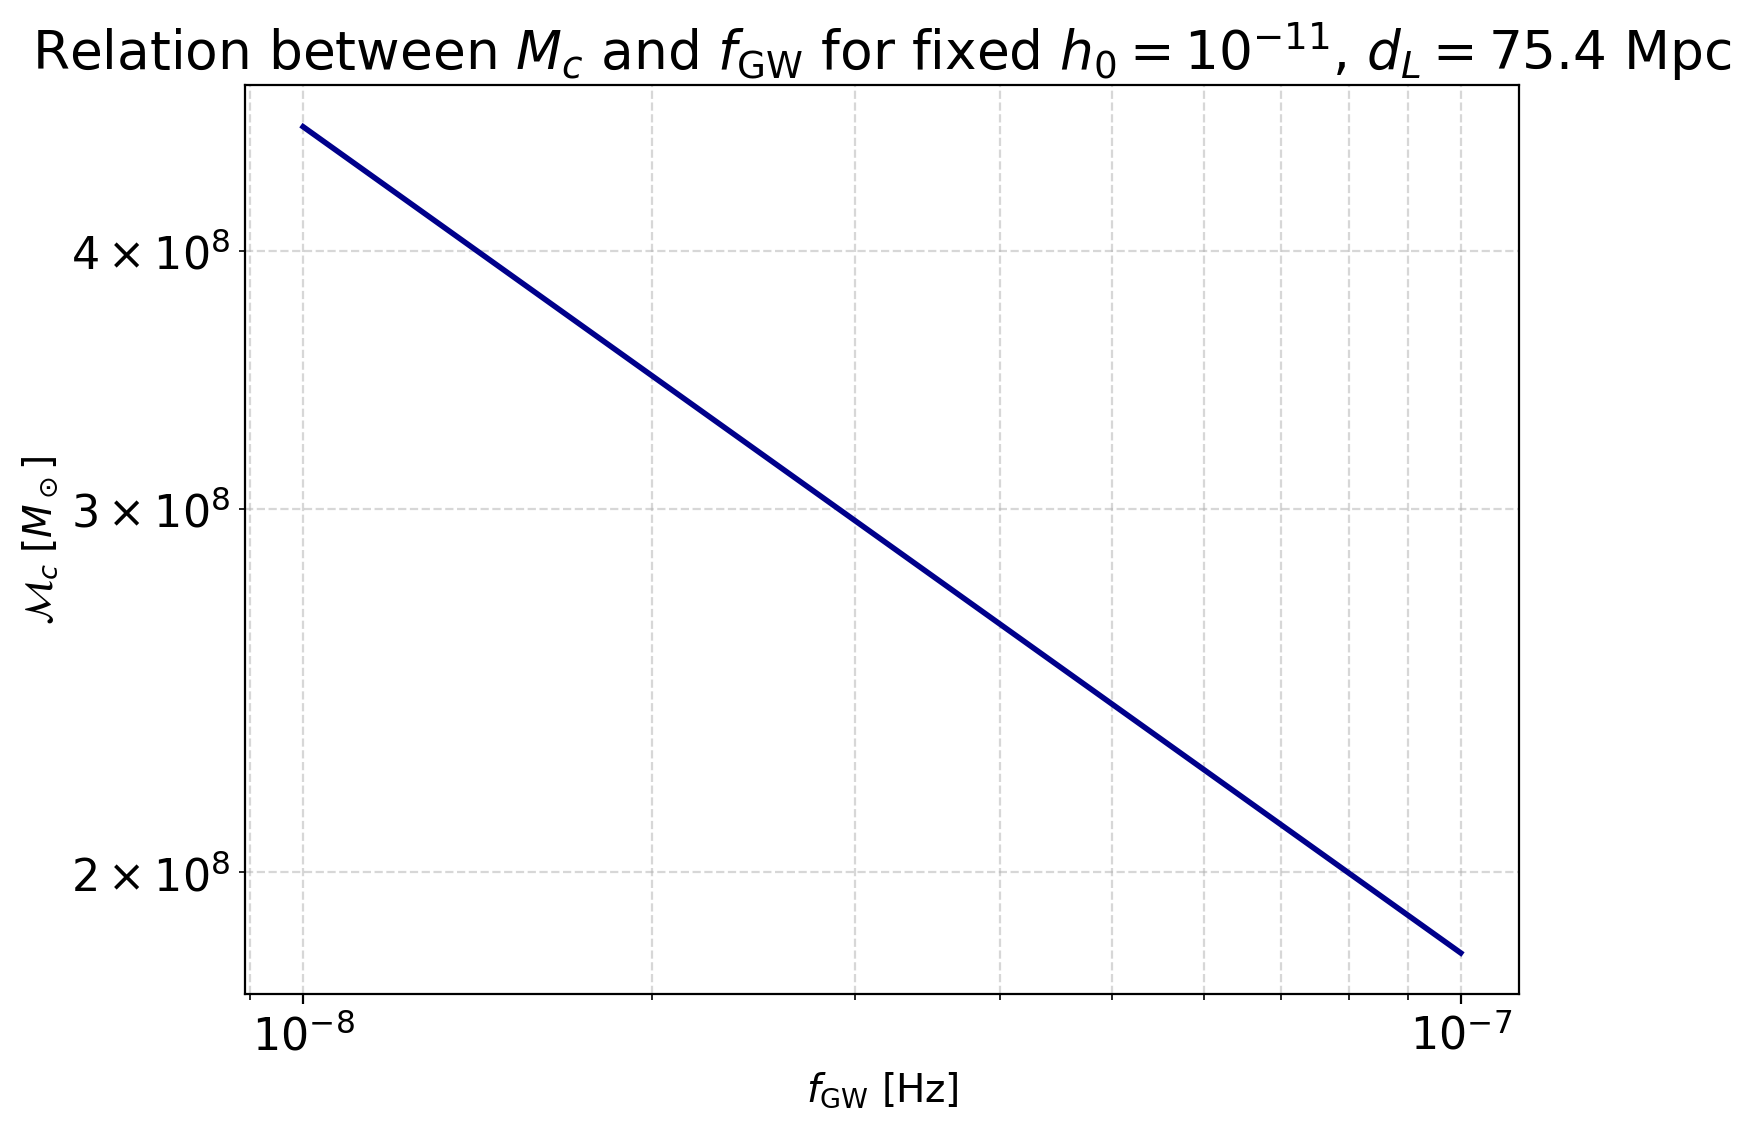

In [26]:

# === Constants ===
megaparsec = 3.086e+22         # meters
speed_of_light = 299792458.0   # m/s
T_sun = 1.327124400e20 / speed_of_light**3  # GM_sun/c^3 in seconds

# === Fixed values ===
h_amp = 1e-15                  # strain amplitude
dL = 75.4 * megaparsec         # luminosity distance in meters

# === Frequency grid (Hz) ===
f_grid = np.logspace(-8, -7, 200)

# === Compute chirp mass (Msun) for each frequency ===
Mc_grid = ( (h_amp * dL) / (2 * speed_of_light * (np.pi * f_grid)**(2/3)) )**(3/5) / T_sun

# === Print some sample values ===
print("f [Hz]         Mc [Msun]")
for f, Mc in zip(f_grid, Mc_grid):
    #print(Mc_grid)
    print(f"{f:.6e}   {Mc:.6e}")

# === Plot ===
plt.figure(figsize=(8,6))
plt.loglog(f_grid, Mc_grid, color='darkblue', lw=2)
plt.xlabel(r'$f_{\rm GW}$ [Hz]', fontsize=14)
plt.ylabel(r'$\mathcal{M}_c \; [M_\odot]$', fontsize=14)
plt.title(r'Relation between $M_c$ and $f_{\rm GW}$ for fixed $h_0=10^{-11}$, $d_L=75.4$ Mpc')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


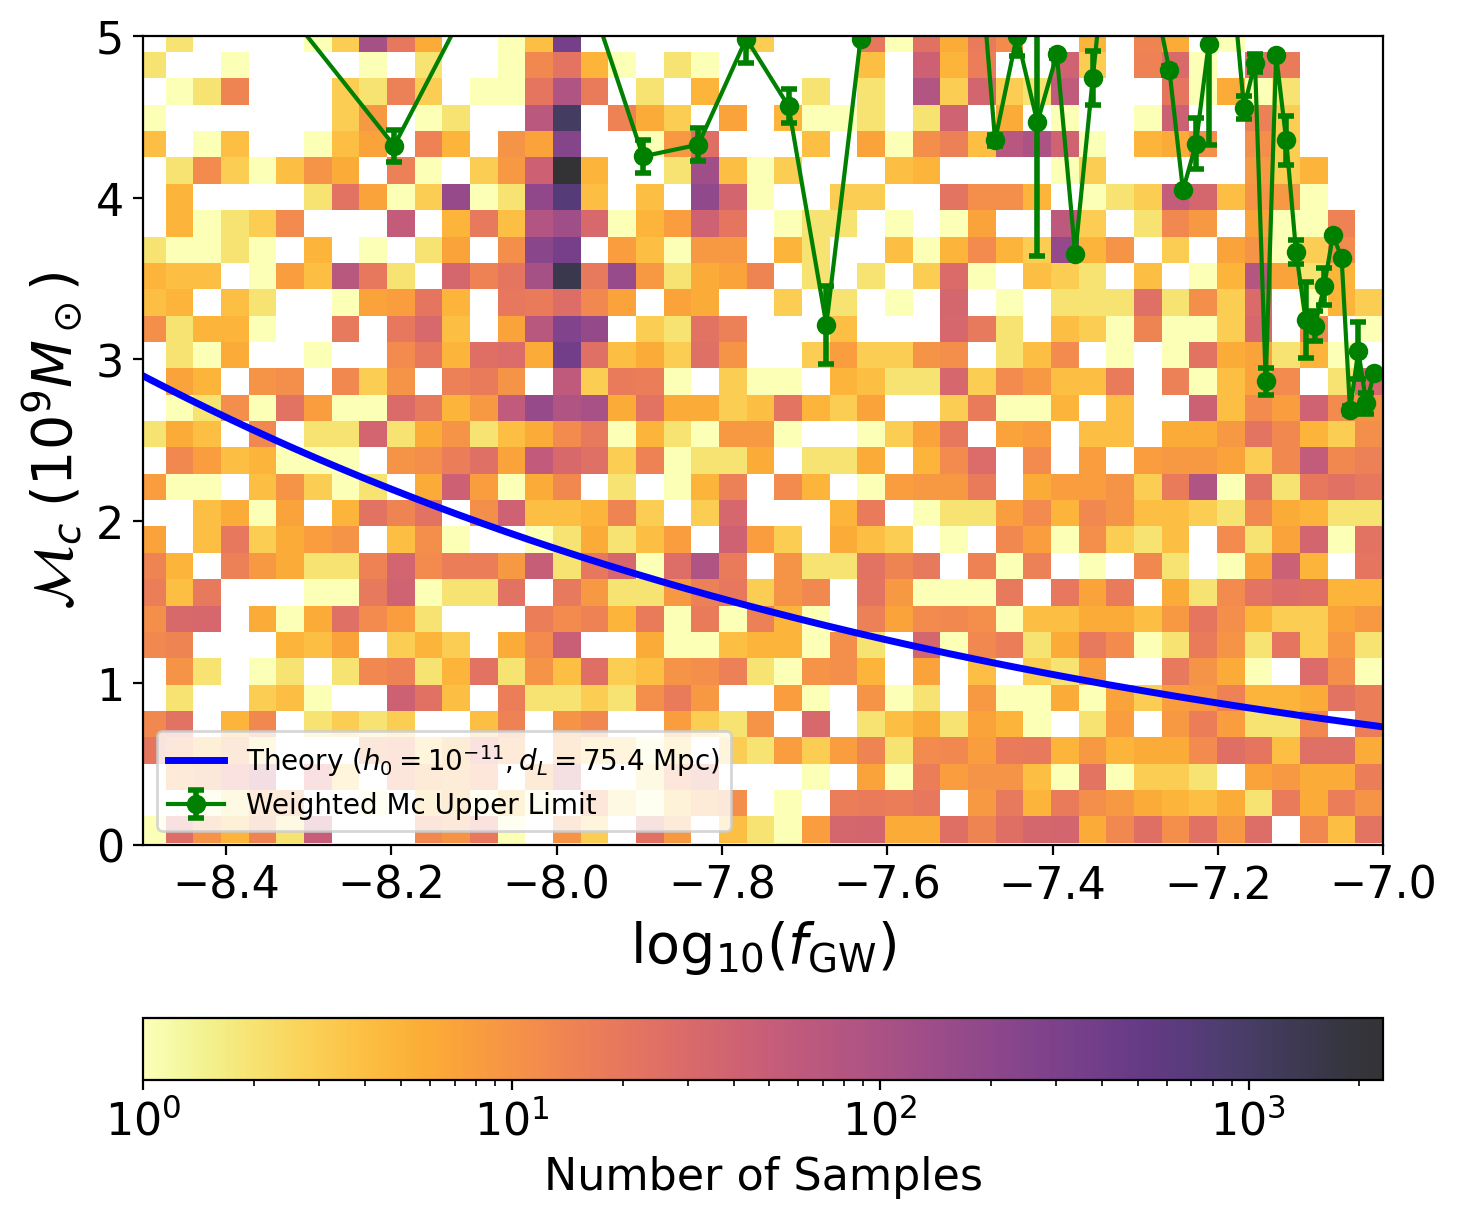

QuickCW Samples (Mc/1e9) [3.272353  1.4446046 1.4446046 1.4446046 1.4446046 1.4446046 1.4446046
 1.4446046 3.0152638 3.0152638 3.0152638 3.0152638 1.5598807 1.8598578
 3.545682  3.545682  3.545682  3.545682  3.545682  3.545682 ]
Theoretical Calculation (Mc/1e9) [3.1771701  3.16780108 3.15845968 3.14914583 3.13985944 3.13060044
 3.12136874 3.11216426 3.10298693 3.09383666 3.08471337 3.07561699
 3.06654742 3.05750461 3.04848846 3.0394989  3.03053584 3.02159922
 3.01268895 3.00380496]
Slopes (Msun per dex):
f=2.51e-09 Hz, Mc=3.18e9 Msun, slope=-2.93e9
f=2.53e-09 Hz, Mc=3.17e9 Msun, slope=-2.92e9
f=2.55e-09 Hz, Mc=3.16e9 Msun, slope=-2.91e9
f=2.57e-09 Hz, Mc=3.15e9 Msun, slope=-2.90e9
f=2.59e-09 Hz, Mc=3.14e9 Msun, slope=-2.89e9


In [27]:
# === Compute theoretical curve of Mc vs f ===
megaparsec = 3.086e+22         # meters
speed_of_light = 299792458.0   # m/s
T_sun = 1.327124400e20 / speed_of_light**3  # GM_sun/c^3 in seconds


h_amp = 1e-14               # fixed strain amplitude
dL = 75.4      # fixed luminosity distance (meters)

# Frequency grid (Hz)
f_grid = np.logspace(-8.6, -7, 500)  # smooth curve
# Corresponding Mc in solar masses
Mc_grid = ( (h_amp * dL* megaparsec ) / (2 * speed_of_light * (np.pi * f_grid)**(2/3)) )**(3/5) / T_sun

# === Overplot on your figure ===
from matplotlib import colors
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,7.5))

# 2D histogram
counts, xbins, ybins, image = ax.hist2d(
    samples2plot[d_L_mask, 3],   # log10(f_GW)
    (10**samples2plot[d_L_mask, 5]) / 1e9,  # Mc in 10^9 Msun
    bins=50,
    norm=colors.LogNorm(),
    alpha=0.8,
    cmap='inferno_r'
)

# Errorbar overlay
ax.errorbar(
    np.log10(fGW_vals), UL_by9, 
    yerr=ULerr_by9, 
    fmt='o', 
    color='g',
    ecolor='green',
    elinewidth=2, 
    capsize=3, 
    capthick=2, 
    linestyle='-', 
    label='Weighted Mc Upper Limit'
)

# Theoretical Mc–f curve overlay
ax.plot(np.log10(f_grid), Mc_grid/1e9, 'b-', lw=2.5, label=r'Theory ($h_0=10^{-11}, d_L=75.4$ Mpc)')

# Colorbar
cbar = plt.colorbar(image, ax=ax, label='Number of Samples', orientation='horizontal')

# Axis formatting
ax.set_xlim(-8.5, -7)
ax.set_ylim(0, 5)
ax.set_xlabel(r'$\log_{10}(f_{\rm GW})$', fontsize=20)
ax.set_ylabel(r'$\mathcal{M}_c \; (10^9 M_\odot)$', fontsize=20)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.legend(fontsize=10)

plt.show()
print("QuickCW Samples (Mc/1e9)", 10**samples2plot[d_L_mask, 5][:20]/1e9)
print("Theoretical Calculation (Mc/1e9)",Mc_grid[:20]/1e9)

slope = -(2/5) * np.log(10) * Mc_grid

# Example: print first few slopes (in Msun per dex)
print("Slopes (Msun per dex):")
for f, Mc, s in zip(f_grid[:5], Mc_grid[:5], slope[:5]):
    print(f"f={f:.2e} Hz, Mc={Mc/1e9:.2f}e9 Msun, slope={s/1e9:.2f}e9")

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# === Strain UL curve from samples ===
UL_h0 = []
h0_lo = []
h0_hi = []

for samples in h0_arr:
    samples = np.array(samples)
    UL_h0.append(np.quantile(samples, 0.95))   # 95% UL
    h0_lo.append(np.quantile(samples, 0.16))   # 16th percentile
    h0_hi.append(np.quantile(samples, 0.84))   # 84th percentile

UL_h0 = np.array(UL_h0)
h0_lo = np.array(h0_lo)
h0_hi = np.array(h0_hi)

# === Plot ===
fig, ax1 = plt.subplots(figsize=(9,6))

# Mc UL (green, left axis)
ax1.errorbar(np.log10(fGW_vals), np.array(UL)/1e9, 
             yerr=np.array(UL_error)/1e9,
             fmt='o', color='g', label=r'$\mathcal{M}_c$ UL (fixed $d_L$)')
ax1.set_ylabel(r'$\mathcal{M}_c \; (10^9 M_\odot)$', color='g', fontsize=14)
ax1.tick_params(axis='y', labelcolor='g')

# Strain UL (blue, right axis, log scale)
ax2 = ax1.twinx()
ax2.plot(np.log10(fGW_vals), UL_h0, 's-', color='b', label=r'$h_0$ UL')
ax2.fill_between(np.log10(fGW_vals), h0_lo, h0_hi, 
                 color='b', alpha=0.2, label=r'$h_0$ 68% CI')
ax2.set_ylabel(r'$h_0$', color='b', fontsize=14)
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='b')

# Common x-axis
ax1.set_xlabel(r'$\log_{10}(f_{\rm GW})$', fontsize=14)
ax1.set_xlim(-8.5, -7)

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Title
plt.title("Comparison of Mc and h0 Upper Limits", fontsize=15)
plt.tight_layout()
plt.show


NameError: name 'h0_arr' is not defined